## Human Activity Recognition for Healthy Lifestyle Monitoring

This project focuses on building a machine learning pipeline to classify five basic human activities: sitting down, standing up, walking, running, and climbing stairs—using smartphone sensor data (accelerometer, gyroscope, gravity).  

**Background and Relevance :**
Human Activity Recognition (HAR) using wearable sensors plays a key role in modern health monitoring, as seen in fitness trackers and smartwatches. Reliable detection of daily activities can support healthy lifestyle interventions, especially for elderly populations. This assignment focuses on five core activities, sitting down, standing up, walking, running, and climbing stairs, to explore how sensor-based data can be transformed into actionable insights for wellness and digital health applications.

**Aim and Research Questions :**
The goal is to develop and evaluate machine learning models that classify these activities using smartphone sensor data to support healthy lifestyle monitoring.

Key questions to address:
1. Which sensor-derived features best distinguish the five target activities?
2. How do supervised vs. unsupervised learning approaches compare for this classification task?
3. Which model achieves the highest accuracy and reliability when combined with appropriate feature extraction and selection?
4. What are the practical considerations and limitations for deploying such systems in real-world health monitoring contexts?


Import Libraries:

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
import os
from pathlib import Path
import pandas as pd
import importlib
import  shutil
import matplotlib.pyplot as plt
import numpy as np

# Add the src folder to the Python module search path
sys.path.append(os.path.abspath("src"))
PROJECT_ROOT = Path.cwd().resolve()
RAW_BASE   = PROJECT_ROOT / "data" / "raw"
TRIMMED_BASE = PROJECT_ROOT / "data" / "trimmed_data"

from data_loader import *
from visualization import *
from preprocessing import *

# Load all data into memory
all_data = load_all_data(RAW_BASE, print_option=False)

Data Loaded
Raw Data Classes: ['running', 'sit_down', 'stairs', 'stand_up', 'walking']


### Data Collection Procedure

We used two different methods for collecting activity data:

1. **Continuous recordings**  
   - Applied to activities such as **running, walking, and climbing stairs**.  
   - These activities can be performed continuously without interruption.  
   - As a result, the recordings are relatively long.

     **Recording Procedure:** The smartphone was secured on the subject’s left upper arm while standing still. The recording began in this position, after which the subject performed the activity, running, walking, or climbing stairs, in a straight line. Once the activity was completed, the subject remained still until the recording was stopped.
     
2. **Single-instance recordings**  
   - Applied to **sitting down** and **standing up** activities.  
   - Each recording contains **only one instance** of the activity.  
   - These recordings are therefore relatively short.

     **Recording Procedure:** For the sitting-down activity, the smartphone was secured on the subject’s left arm while they stood still in front of a chair. Recording began, and after 1–2 seconds the subject performed the sitting-down action. The recording continued for another 1–2 seconds while the subject remained seated, then was stopped. The same procedure was followed for the standing-up activity.

Below are the visualized plots of **raw** accelerometer, gyroscope, and gravity sensor recordings from randomly selected samples of each activity group.

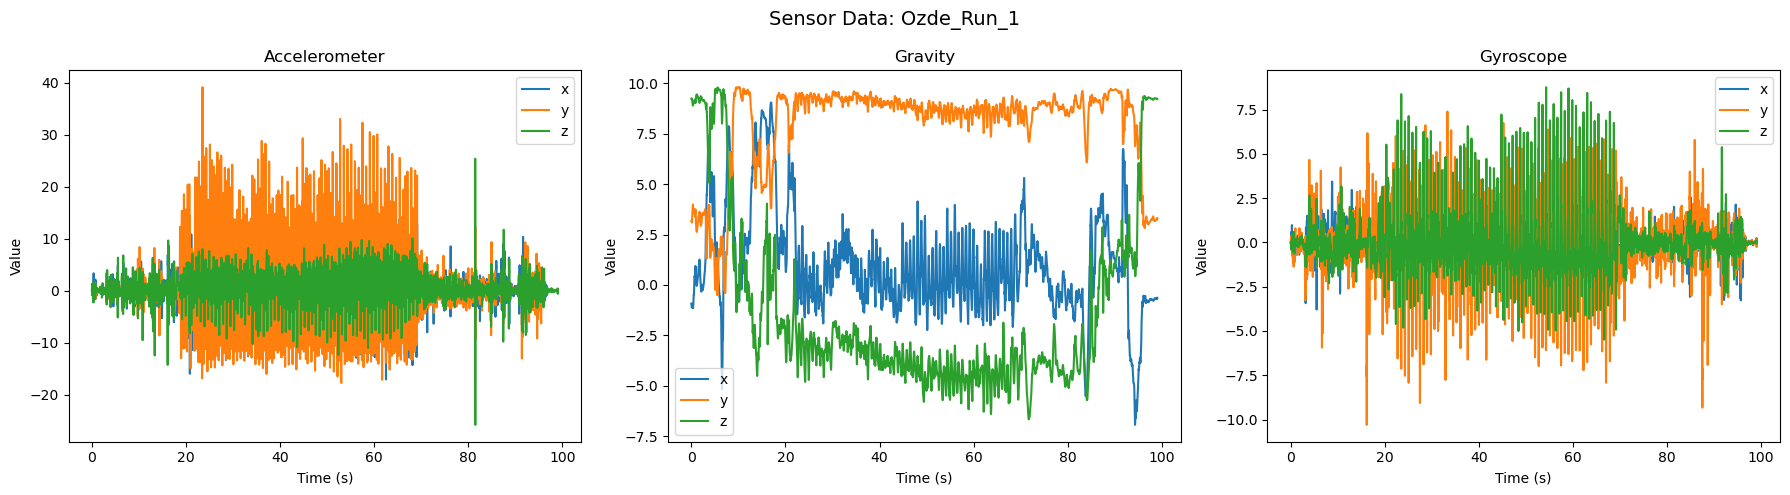

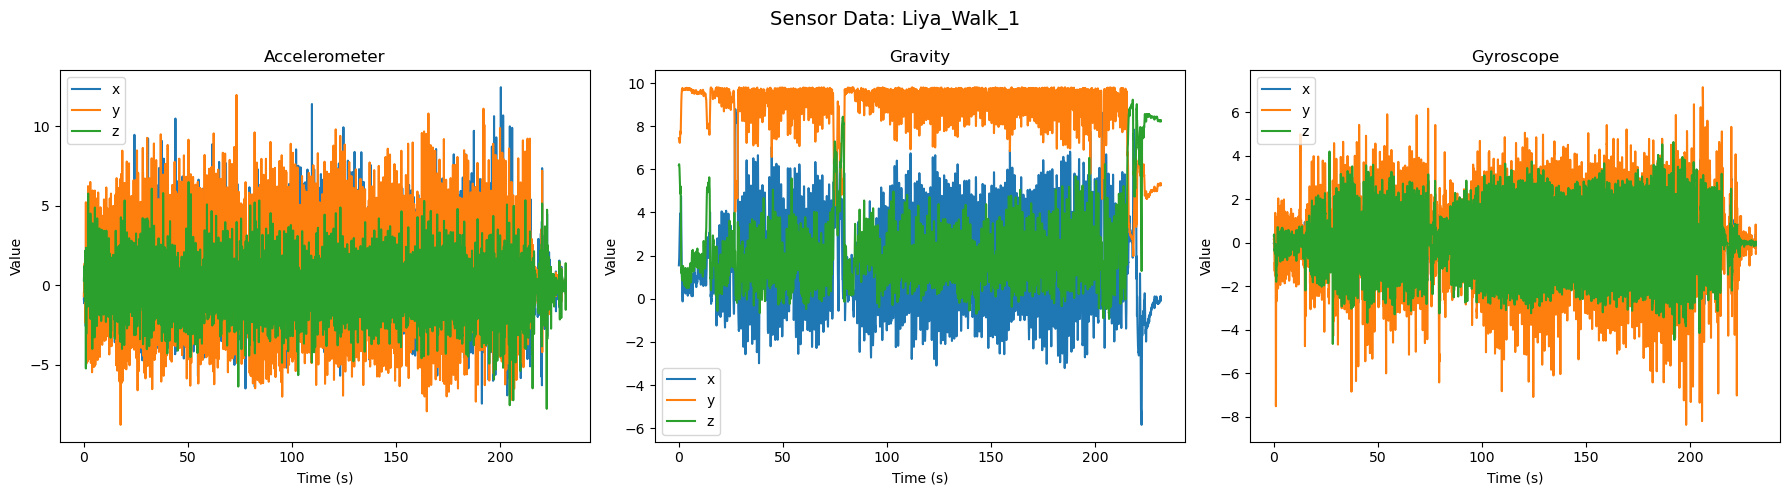

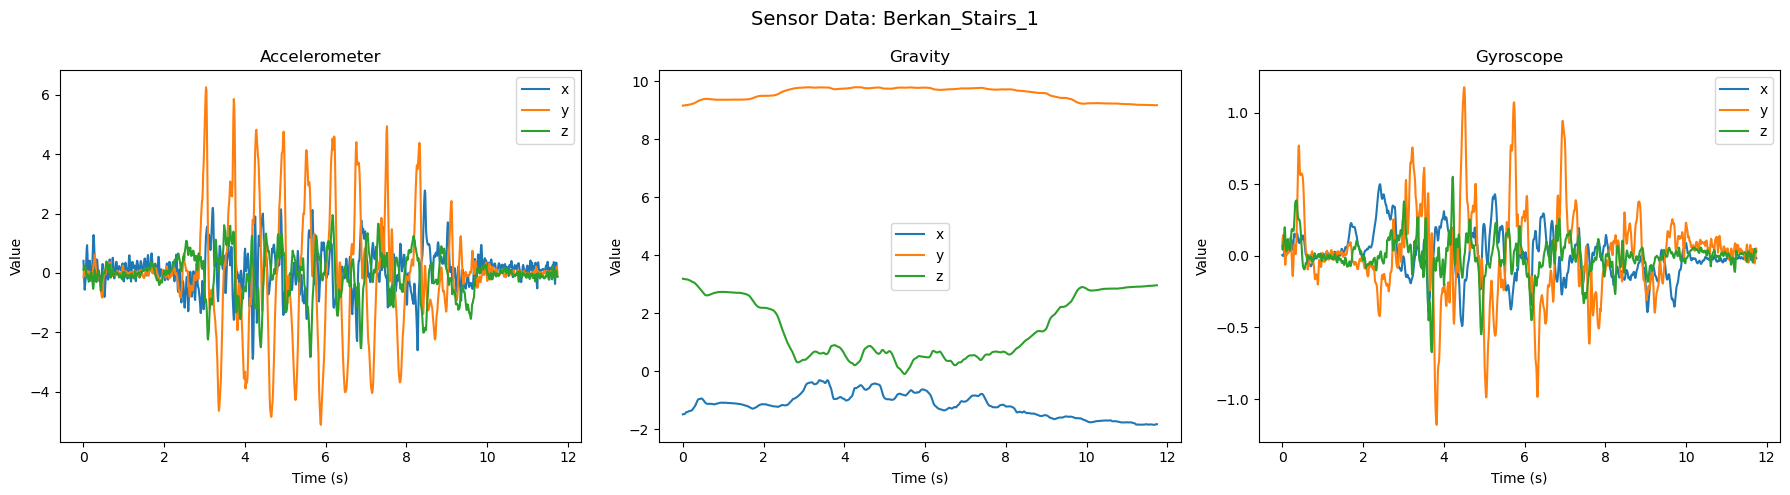

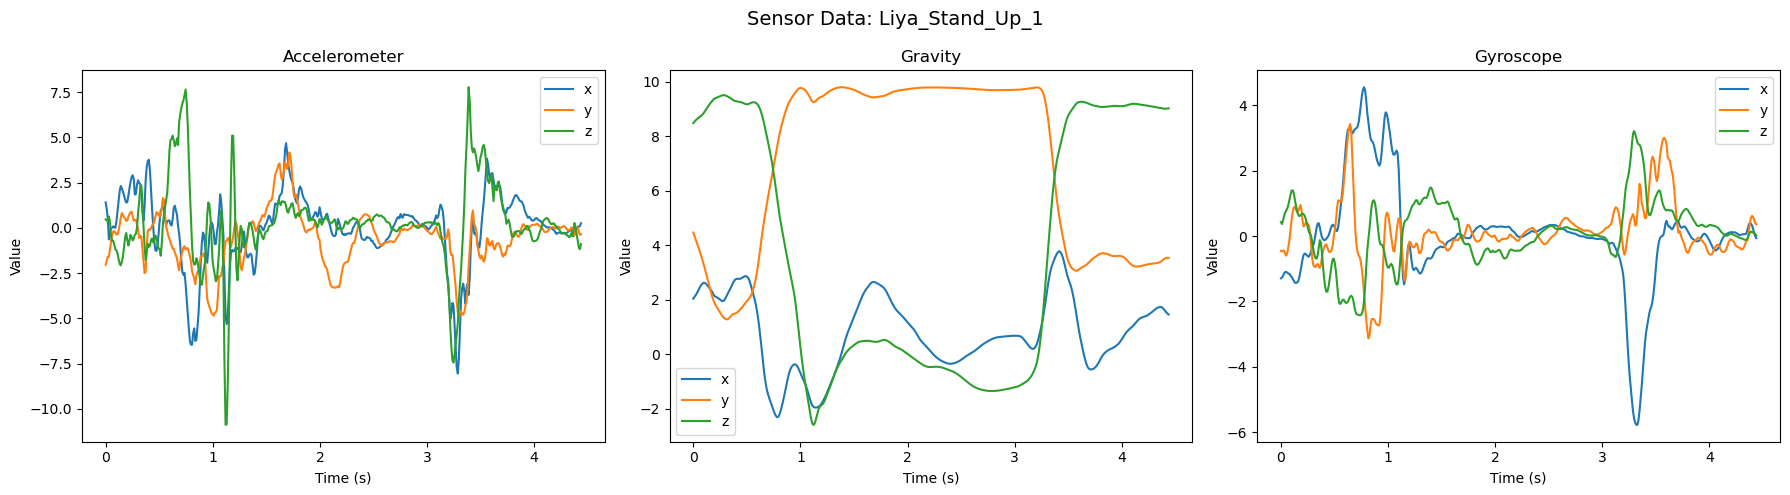

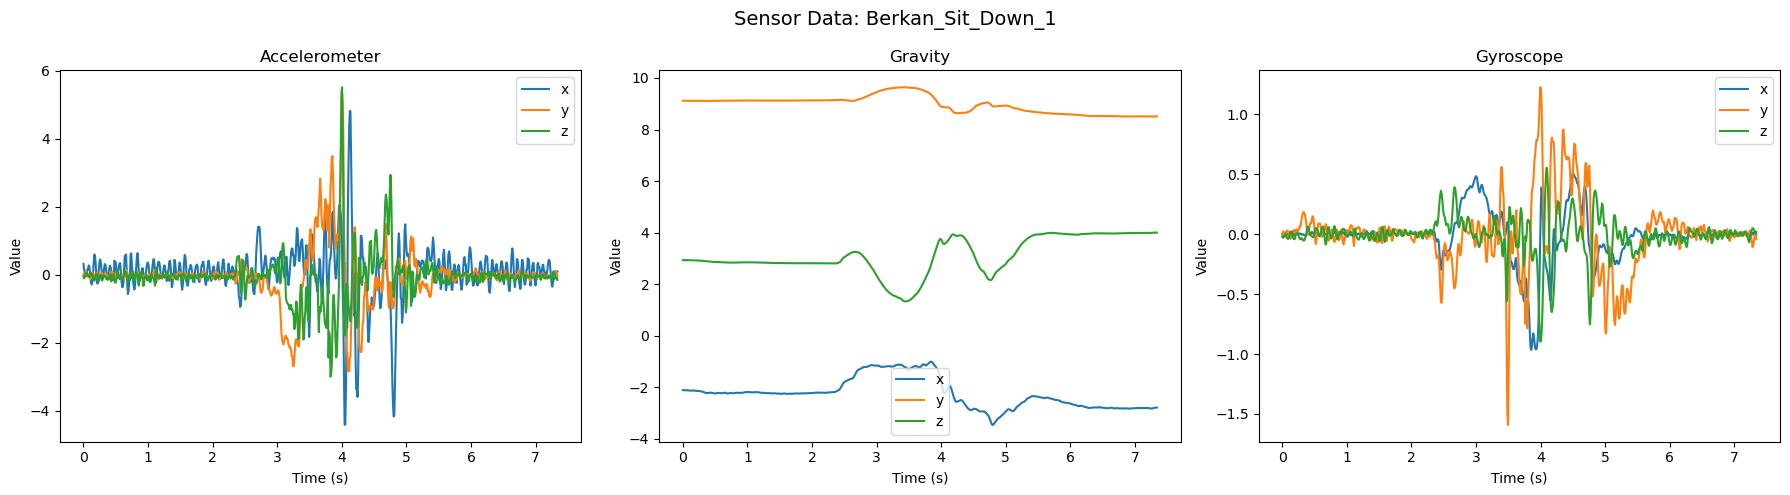

In [ ]:
plot_activity(RAW_BASE / "running" / "Ozde_Run_1")
plot_activity(RAW_BASE / "walking" / "Liya_Walk_1")
plot_activity(RAW_BASE / "stairs" / "Berkan_Stairs_1")
plot_activity(RAW_BASE / "stand_up" / "Liya_Stand_Up_1")
plot_activity(RAW_BASE / "sit_down" / "Berkan_Sit_Down_1")

The three sensors used to measure the data consists of the following: 

1. Accelerometer: Measures linear acceleration of the body in three axes (x, y, z) capturing movement intensity such as steps.

2. Gravity Sensor: Detects the orientation and tilt of the body relative to the Earth's gravity. 

3. Gyroscope: Measures angular velocity or rotational motion around the three axes. This allows twists and turns to be captured.

We start processing the raw data by first removing the inactive segments at the beginning and end of each recording, retaining only the portion where the activity is actually performed.
Additionally, we discard any segments recorded while placing the phone into the armband, as these movements do not represent the target activity.

The following observations were made with respect to the activities below:

- The accelerometer and gyroscope signals in the middle phase which is the region of interest, display strong, rhythmic oscillations which correspond to foot strikes and body rotation during a run. The gravity sensor remains relatively stable, indicating consistent sensor orientation.

- The walking sensor data shows relatively consistent, lower-amplitude oscillations compared to running. This reflects the slower and steadier pattern obtained during walking. The accelerometer and gyroscope signals maintain moderate fluctuations throughout most of the session, lacking the sharp spikes seen in running, and the gravity readings remain mostly stable with small shifts due to subtle changes in orientation. This steadiness highlights the lower-impact, motion characteristic of walking.

- The stairs activity shows more ryhthmic and high-amplitude oscillations in the accelerometer, especially in the y-axis, which captures the vertical up-and-down motion of climbing. Compared to walking, these oscillations are more intense but less erratic than running. The gyroscope data also shows bursts of angular motion that align with the steps taken. This is an indication of frequent shifts in leg and body orientation. Meanwhile, the gravity signals change gradually over time, reflecting the tilt of the body as the subject moves upward and then stabilizes when standing still. This pattern highlights the stepwise, periodic nature of stair climbing.

- The standing-up motion shows short and sharp bursts in the accelerometer, especially in the z-axis. This corresponds to the quick upward push off the chair. The gyroscope data reflects strong angular movements at the start and end of the motion. Most likely reflecting the movement of the body as it leans forward and then straightens. The gravity signals exhibit a clear transition, with all three axes shifting rapidly, showing the change from a seated to an upright posture. This pattern highlights a brief event followed by stability once the position is fully standing.

- The sitting-down motion shows again a short and intense burst in the accelerometer signals, most prominently in the x and z axes. This corresponds to the controlled descent into the seat. The gyroscope data captures angular rotation during the leaning phase, peaking around the midpoint of the motion before stabilizing. The gravity plot shows a gradual transition for tilt as the body transitions from upright to seated, with the z-axis increasing and the x-axis decreasing, this clearly marks the posture change.





- **For Continuous activities (running / walking / climbing stairs):** Each recording was trimmed to remove non-activity segments and then divided into multiple data samples using 3-second windows with 50% overlap.

All three trimming functions work the same way. They automatically detect when the activity starts and ends by measuring how strong the motion signal is.

- For running and walking the y-axis of the accelerometer is used. The RMS (energy) is calculated by sliding a short window across the signal.

- For stairs, the gravity signal's magnitude is used, since body tilt changes more clearlycapturing stair climbing.

- A specific threshold was defined for each funciton that is used to make the initial cut when the first treshold is passed and one to make the second trim when the RMS value falls below the second treshold value.

Each trimming function can generate a debug plot that shows the sensor signal, the RMS energy curve, the start/end thresholds, and vertical lines marking the detected trim boundaries.
These plots are extremely useful to visually confirm that the automatic cuts are correct; you should see the trim markers line up with the start and end of the actual activity burst.

In [174]:
WINDOW_SIZE = 3.0 #Seconds

preprocess_running(TRIMMED_BASE, all_data, window_size=WINDOW_SIZE, show_plots=False) # show_plots=False to disable plots
preprocess_walking(TRIMMED_BASE, all_data, window_size=WINDOW_SIZE, show_plots=False) # show_plots=False to disable plots
preprocess_stairs(TRIMMED_BASE, all_data, window_size=WINDOW_SIZE, show_plots=False)  # show_plots=False to disable plots


 Processing running | Folder: Berkan_Run_1
  Trim 7.50 → 65.90, 38 windows, saved in C:\Users\ozdep\Documents\data analytics\Data-Analytics-and-Learning-Methods\data\trimmed_data\running

 Processing running | Folder: Berkan_Run_2
  Trim 7.51 → 67.41, 39 windows, saved in C:\Users\ozdep\Documents\data analytics\Data-Analytics-and-Learning-Methods\data\trimmed_data\running

 Processing running | Folder: Ozde_Run_1
  Trim 20.96 → 67.26, 29 windows, saved in C:\Users\ozdep\Documents\data analytics\Data-Analytics-and-Learning-Methods\data\trimmed_data\running

 Processing running | Folder: Ozde_Run_2
  Trim 12.00 → 82.19, 45 windows, saved in C:\Users\ozdep\Documents\data analytics\Data-Analytics-and-Learning-Methods\data\trimmed_data\running

 Processing running | Folder: Ozde_Run_3
  Trim 19.47 → 80.70, 39 windows, saved in C:\Users\ozdep\Documents\data analytics\Data-Analytics-and-Learning-Methods\data\trimmed_data\running

 Processing running | Folder: Ozde_Run_4
  Trim 17.98 → 79.21,

Example plot of the RMS Intersection Based Trim Detection Procedure for Raw Running Recordings:

![](figures\running_rms_intersection_based_trim_detection.png)

Initial trim is made when the initial value passes the starting treshold value and the ending trim is done when the RMS value drops below the defined end trim. The corresponding cuts can be seen on the accelerometer plot where you can see that the cuts dont include the initial and end noise captured before and after the activity is taking place

Example plot of the RMS Intersection Based Trim Detection Procedure for Raw Walking Recordings:

![](figures\walking_rms_intersection_based_trim_detection.png)

[Explanation of this plot goes here: How the RMS energy used to find the trimming points etc.]

Here the corresponding accelerometer plot can also be visualized with the RMS plots for one of the stairs data. It can be seen that the trims do not capture the noise present at the start and end of the raw data.
![](figures/rms_intersection.png)  
![](figures/corresponding_rms_trim_accl.png)



- **For single-instance activities (sit-down / stand-up):**
Each single-instance activity (sit-down / stand-up) was trimmed to a 3-second window, centered on the activity itself, to remove non-activity segments.

In [175]:
WINDOW_SIZE = 3.0 #Seconds

results = trim_sitdown_standup(RAW_BASE, TRIMMED_BASE, window_size=WINDOW_SIZE)

Done. Processed: 60 | Skipped: 0


[An explanation of the trimming procedure of sitdown and standup activities will added here with a plot]

After trimming, each activity segment was split into 3-second windows with 50 % overlap.
The overlap means each new window starts halfway through the previous one, which increases the number of training samples available from the same recording while also preserving the pattern of the activity. Below an example of the overlapping window frames can be visualized for the stairs class.


![](figures/stairs_overlap.png)

Now we can collect all windowed activity data into a single CSV file.

[Also Explain which/why features are extracted from x, y and z sensor recordings]

In [177]:
from create_csv import *

DATASET_PATH = PROJECT_ROOT / "dataset.csv"

audit_windows(TRIMMED_BASE)
df = build_dataset_from_windowed_data(TRIMMED_BASE, DATASET_PATH, keep_ids=True)

[Audit]
  - running: expected=276, usable=276, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - sit_down: expected=30, usable=30, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - stairs: expected=31, usable=31, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - stand_up: expected=30, usable=30, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - walking: expected=481, usable=481, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}

Total window folders: 848 | Usable (all three files OK): 848

[Activity] running
  Processed 250 windows...

[Activity] sit_down

[Activity] stairs

[Activity] stand_up

[Activity] walking
  Processed 500 windows...
  Processed 750 windows...

[Done] Wrote 848 rows × 167 columns to: C:

## Load the dataset
- First column is label (y)
- Remaining are features (X)

In [8]:
DATASET_PATH = PROJECT_ROOT / "dataset.csv"

df = pd.read_csv(DATASET_PATH)

X = df.iloc[:, 1:]
y = df.iloc[:, 0]

print("Loaded dataset.csv with shape:", df.shape)
print("Target name:", df.columns[0])
print("Num features:", X.shape[1])

df.head(3)# 12345

Loaded dataset.csv with shape: (856, 167)
Target name: activity
Num features: 166


,activity,acc_corr_x_y,acc_corr_x_z,acc_corr_y_z,acc_mag_dom_freq,acc_mag_iqr,acc_mag_kurtosis,acc_mag_max,acc_mag_mean,acc_mag_median,...,gyro_z_mean,gyro_z_median,gyro_z_min,gyro_z_rms,gyro_z_skew,gyro_z_spec_centroid,gyro_z_spec_energy,gyro_z_spec_entropy,gyro_z_std,person
0,running,-0.422285,-0.255755,-0.025324,5.0,6.662222,-0.093018,23.414247,9.195592,9.040583,...,-0.017501,-0.035374,-1.221355,0.420798,0.278885,4.202507,11.759396,3.036354,0.421137,Berkan
1,running,-0.068380,-0.043782,-0.262769,5.0,5.756685,-0.737154,18.871659,9.020759,9.577971,...,0.038710,0.124412,-1.495412,0.619739,-0.194350,2.548933,19.232855,2.127987,0.619562,Berkan
2,running,-0.110942,0.009237,-0.290851,5.0,5.511045,-0.709310,17.660803,8.971730,9.589745,...,0.085773,0.187724,-1.495412,0.598747,-0.249874,2.659217,22.169449,2.251347,0.593562,Berkan


## Split data into Train and Test set
We split the data into training and test datsets with a 80/20 train/test ratio. This is done in a stratified manner. Afterwards we scale the data for effective training.


In [12]:
# imports
from sklearn.preprocessing import StandardScaler
from preprocessing import stratified_person_label_split

X_train, y_train, X_test, y_test, info = stratified_person_label_split(X,y,test_ratio=0.20,random_state=42)

print(info["sizes"])
print(info["ratios"])
print("Classes:", info["class_dist"])
print("People:", info["person_dist"])

# --- StandardScaler setup ---
scaler = StandardScaler()

print(X_train.dtypes)
print(X_train.head())

# Keep only numeric columns
X_train_num = X_train.select_dtypes(include=["number"])
X_test_num  = X_test.select_dtypes(include=["number"])

# Scale numeric features only
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_num),
    columns=X_train_num.columns,
    index=X_train.index)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_num),
    columns=X_test_num.columns,
    index=X_test.index)


{'train': 685, 'test': 171, 'total': 856}
{'train': 0.8002336448598131, 'test': 0.19976635514018692}
Classes: {'train': {'running': 221, 'sit_down': 24, 'stairs': 31, 'stand_up': 24, 'walking': 385}, 'test': {'running': 55, 'sit_down': 6, 'stairs': 8, 'stand_up': 6, 'walking': 96}}
People: {'train': {'Berkan': 131, 'Liya': 329, 'Ozde': 225}, 'test': {'Berkan': 33, 'Liya': 82, 'Ozde': 56}}
acc_corr_x_y            float64
acc_corr_x_z            float64
acc_corr_y_z            float64
acc_mag_dom_freq        float64
acc_mag_iqr             float64
                         ...   
gyro_z_spec_centroid    float64
gyro_z_spec_energy      float64
gyro_z_spec_entropy     float64
gyro_z_std              float64
person                   object
Length: 166, dtype: object
     acc_corr_x_y  acc_corr_x_z  acc_corr_y_z  acc_mag_dom_freq  acc_mag_iqr  \
261     -0.017045      0.295344     -0.266787          4.983389     8.331910   
542     -0.223268      0.183530      0.328016          1.010101     2

# Feature Selection
- **Filter Methods:** Variance -> Correlation -> Mutual Information
- **Wrapper Methods:** Recursive Feature Elimination (RFE) + Sequential Feature Selection (SFS) forward/backward

All performed on `dataset.csv` (explained above how this dataset is obtained).


In [18]:
## Imports & Code Paths 

import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.feature_selection import RFE, SequentialFeatureSelector
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, cohen_kappa_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.decomposition import PCA
from functools import partial
from sklearn.metrics import accuracy_score, silhouette_score 
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score


# Our feature selection toolkit (from feature_selection.py)
from feature_selection import (
    filter_select,
    wrapper_select,
    plot_correlation_heatmap,
    accuracy_vs_k_MI,
    pca_explained_variance
)

import os
# Paths & directories (safe to run multiple times)
# (Creates ./figures if it doesn't exist for saved plots)
os.makedirs("figures", exist_ok=True)


## Filter Methods
We use 3 filters succesively:
- **Variance:** Removes exactly-constant (dead) features
- **Correlation:** Drop one of each highly correlated pair of features
- **Mutual Information (MI):** Keep top-K features by MI with class labels 

In [16]:
# FILTERS: variance -> correlation -> MI-KBest
Xf_train, names_f, report = filter_select(
    X_train_scaled, y_train,
    variance_thresh=0.0,       #threshold for removing ONLY exactly-constant features
    corr_thresh=0.90,          #feature-feature absolute correlation threshold
    k_best=40,                 #integer: keep top-k by mutual information; None to skip
    scale_for_mi=True,         
    mi_n_neighbors=5,          #how many neighbors to use for MI selection
    mi_random_state=42         #fixed random_state for reproducibility
)
print("Filter report:", report)

# Apply same feature subset to both train and test
X_train_fs = X_train_scaled[names_f]
X_test_fs  = X_test_scaled[names_f]

[VarianceThreshold] Kept: 165, Removed: 0
[CorrelationFilter] Kept: 108, Removed: 57 (|r| > 0.9)
Removed highly correlated features: ['acc_mag_max', 'acc_mag_mean', 'acc_mag_median', 'acc_mag_rms', 'acc_mag_spec_energy', 'acc_mag_std', 'acc_x_min', 'acc_x_rms', 'acc_x_spec_energy', 'acc_x_std', 'acc_y_iqr', 'acc_y_max', 'acc_y_min', 'acc_y_rms', 'acc_y_spec_energy', 'acc_y_std', 'acc_z_iqr', 'acc_z_mean', 'acc_z_median', 'acc_z_rms', 'acc_z_spec_energy', 'acc_z_std', 'grav_mag_iqr', 'grav_mag_max', 'grav_mag_median', 'grav_mag_rms', 'grav_mag_spec_energy', 'grav_mag_std', 'grav_x_median', 'grav_x_spec_energy', 'grav_x_std', 'grav_y_median', 'grav_y_rms', 'grav_y_std', 'grav_z_max', 'grav_z_mean', 'grav_z_median', 'grav_z_min', 'grav_z_std', 'gyro_mag_max', 'gyro_mag_median', 'gyro_mag_rms', 'gyro_mag_spec_energy', 'gyro_mag_std', 'gyro_x_spec_energy', 'gyro_x_std', 'gyro_y_max', 'gyro_y_rms', 'gyro_y_spec_energy', 'gyro_y_std', 'gyro_z_iqr', 'gyro_z_max', 'gyro_z_min', 'gyro_z_rms', 'g

Baseline CV performance (5-fold, training set only):

LogisticRegression:
  Accuracy : 0.9796 ± 0.0107
  Kappa    : 0.9646 ± 0.0185
  F1-macro : 0.9220 ± 0.0386

KNN:
  Accuracy : 0.9737 ± 0.0127
  Kappa    : 0.9546 ± 0.0219
  F1-macro : 0.8956 ± 0.0612

NaiveBayes:
  Accuracy : 0.9372 ± 0.0164
  Kappa    : 0.8949 ± 0.0245
  F1-macro : 0.8405 ± 0.0457

DecisionTree:
  Accuracy : 0.9796 ± 0.0097
  Kappa    : 0.9647 ± 0.0162
  F1-macro : 0.9342 ± 0.0304


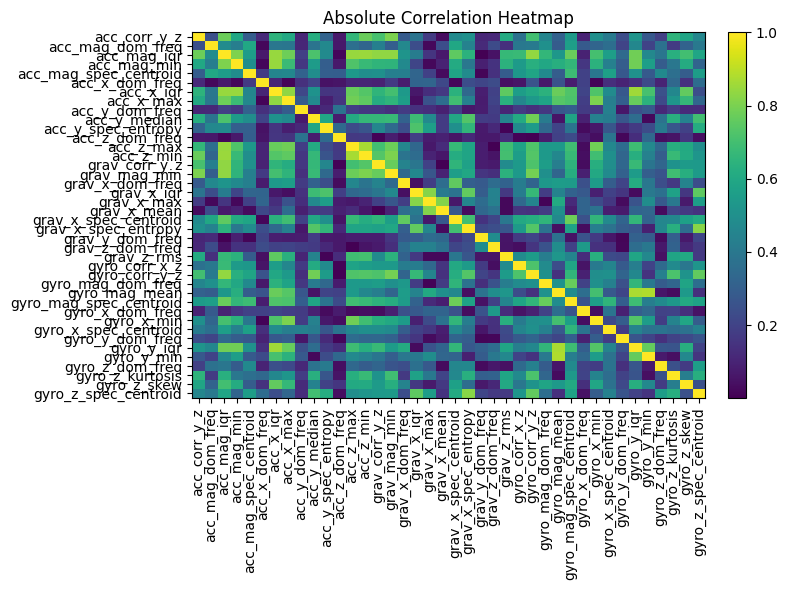

Saved correlation heatmap to corr_heatmap.png


In [20]:
#Intermediate Results
#Baseline models on filtered features (accuracy on held-out test set )
models = {
    "LogisticRegression": LogisticRegression(max_iter=5000, solver="lbfgs", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "NaiveBayes": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(random_state=42)
}

# Define custom scorers
scorers = {
    "accuracy": make_scorer(accuracy_score),
    "kappa": make_scorer(cohen_kappa_score),
    "f1_macro": make_scorer(f1_score, average="macro")  # macro for multiclass
}

print("Baseline CV performance (5-fold, training set only):")
for name, clf in models.items():
    cv_results = cross_validate(clf, X_train_fs.values, y_train, cv=cv, scoring=scorers)
    acc_mean, acc_std = cv_results["test_accuracy"].mean(), cv_results["test_accuracy"].std()
    kappa_mean, kappa_std = cv_results["test_kappa"].mean(), cv_results["test_kappa"].std()
    f1_mean, f1_std = cv_results["test_f1_macro"].mean(), cv_results["test_f1_macro"].std()

    print(f"\n{name}:")
    print(f"  Accuracy : {acc_mean:.4f} ± {acc_std:.4f}")
    print(f"  Kappa    : {kappa_mean:.4f} ± {kappa_std:.4f}")
    print(f"  F1-macro : {f1_mean:.4f} ± {f1_std:.4f}")

# Optional: visualize correlation after variance filtering
# Correlation heatmap (saved to figures/, non-blocking)
plot_correlation_heatmap(pd.DataFrame(Xf_train, columns=names_f), show=True, block=False, save_path="figures/corr_heatmap.png")
print("Saved correlation heatmap to corr_heatmap.png")

## Wrapper Methods
XXXXX

In [ ]:
# Wrapper: RFE + Logistic Regression (CV summary on train only)
Xw_lr_train, names_lr, info_lr = wrapper_select(
    X_train_fs, y_train,
    method="rfe",
    n_features_to_select=min(15, X_train_fs.shape[1]),
    estimator=LogisticRegression(max_iter=5000, solver="lbfgs", random_state=42),
    cv_splits=5,
    scale_inputs=True
)

[Wrapper-RFE] Kept: 15 features
  Accuracy : 0.9956 ± 0.0058
  Kappa    : 0.9923 ± 0.0103
  F1-macro : 0.9881 ± 0.0160
  Selected features: ['acc_corr_y_z', 'acc_mag_dom_freq', 'acc_mag_iqr', 'acc_mag_spec_centroid', 'acc_y_dom_freq', 'acc_y_median', 'acc_y_spec_entropy', 'grav_corr_y_z', 'gyro_corr_x_z', 'gyro_mag_mean', 'gyro_mag_spec_centroid', 'gyro_x_min', 'gyro_y_iqr', 'gyro_z_skew', 'gyro_z_spec_centroid']
RFE + LR selected: ['acc_corr_y_z', 'acc_mag_dom_freq', 'acc_mag_iqr', 'acc_mag_spec_centroid', 'acc_y_dom_freq', 'acc_y_median', 'acc_y_spec_entropy', 'grav_corr_y_z', 'gyro_corr_x_z', 'gyro_mag_mean', 'gyro_mag_spec_centroid', 'gyro_x_min', 'gyro_y_iqr', 'gyro_z_skew', 'gyro_z_spec_centroid']
  Accuracy : 0.9956 ± 0.0058
  F1-macro : 0.9881 ± 0.0160
  Kappa    : 0.9923 ± 0.0103


In [22]:
# Wrapper: SFS (forward) + KNN (works well for distance-based models)
Xw_knn_train, names_knn, info_knn = wrapper_select(
    X_train_fs, y_train,
    method="sfs_forward",
    n_features_to_select=min(15, X_train_fs.shape[1]),
    estimator=KNeighborsClassifier(n_neighbors=5),
    cv_splits=5,
    scale_inputs=True
)

[Wrapper-SFS:forward] Kept: 15 features
  Accuracy : 0.9956 ± 0.0058
  F1-macro : 0.9875 ± 0.0170
  Kappa    : 0.9923 ± 0.0102
  Selected features: ['acc_mag_dom_freq', 'acc_mag_iqr', 'acc_mag_min', 'acc_x_iqr', 'acc_x_max', 'acc_y_dom_freq', 'acc_y_median', 'acc_y_spec_entropy', 'acc_z_max', 'grav_x_iqr', 'grav_x_mean', 'gyro_corr_y_z', 'gyro_mag_mean', 'gyro_x_spec_centroid', 'gyro_y_iqr']


In [25]:
# Wrapper: SFS (forward) + Naive Bayes
Xw_nb_train, names_nb, info_nb = wrapper_select(
    X_train_fs, y_train,
    method="sfs_forward",
    n_features_to_select=min(15, X_train_fs.shape[1]),
    estimator=GaussianNB(),
    cv_splits=5,
    scale_inputs=True
)

[Wrapper-SFS:forward] Kept: 15 features
  Accuracy : 0.9942 ± 0.0055
  F1-macro : 0.9754 ± 0.0293
  Kappa    : 0.9898 ± 0.0095
  Selected features: ['acc_corr_y_z', 'acc_mag_dom_freq', 'acc_mag_iqr', 'acc_mag_spec_centroid', 'acc_y_dom_freq', 'acc_y_median', 'acc_y_spec_entropy', 'grav_corr_y_z', 'grav_x_mean', 'grav_y_dom_freq', 'grav_z_rms', 'gyro_corr_x_z', 'gyro_mag_dom_freq', 'gyro_x_min', 'gyro_y_iqr']


In [26]:
# Wrapper: RFE + Decision Tree (trees don't need scaling)
Xw_dt_train, names_dt, info_dt = wrapper_select(
    X_train_fs, y_train,
    method="rfe",
    n_features_to_select=min(15, X_train_fs.shape[1]),
    estimator=DecisionTreeClassifier(random_state=42),
    cv_splits=5,
    scale_inputs=False
)

[Wrapper-RFE] Kept: 15 features
  Accuracy : 0.9825 ± 0.0099
  Kappa    : 0.9699 ± 0.0165
  F1-macro : 0.9394 ± 0.0256
  Selected features: ['acc_mag_iqr', 'acc_x_dom_freq', 'acc_x_iqr', 'acc_x_max', 'acc_y_dom_freq', 'acc_y_median', 'acc_y_spec_entropy', 'gyro_mag_dom_freq', 'gyro_mag_mean', 'gyro_mag_spec_centroid', 'gyro_x_dom_freq', 'gyro_x_min', 'gyro_x_spec_centroid', 'gyro_y_dom_freq', 'gyro_y_iqr']


[VarianceThreshold] Kept: 165, Removed: 0
[CorrelationFilter] Kept: 128, Removed: 37 (|r| > 0.95)
Removed highly correlated features: ['acc_mag_mean', 'acc_mag_median', 'acc_mag_rms', 'acc_mag_spec_energy', 'acc_mag_std', 'acc_x_rms', 'acc_x_spec_energy', 'acc_x_std', 'acc_y_iqr', 'acc_y_max', 'acc_y_min', 'acc_y_rms', 'acc_y_spec_energy', 'acc_y_std', 'acc_z_iqr', 'acc_z_median', 'acc_z_rms', 'acc_z_spec_energy', 'acc_z_std', 'grav_mag_rms', 'grav_mag_spec_energy', 'grav_mag_std', 'grav_x_median', 'grav_x_spec_energy', 'grav_x_std', 'grav_y_rms', 'grav_z_mean', 'grav_z_median', 'grav_z_std', 'gyro_mag_median', 'gyro_mag_rms', 'gyro_mag_std', 'gyro_x_std', 'gyro_y_rms', 'gyro_y_std', 'gyro_z_spec_energy', 'gyro_z_std']
Correlated pairs (kept -> removed, r):
  acc_mag_iqr -> acc_mag_mean (r=0.973)
  acc_mag_max -> acc_mag_mean (r=0.954)
  acc_mag_iqr -> acc_mag_median (r=0.959)
  acc_mag_mean -> acc_mag_median (r=0.993)
  acc_mag_iqr -> acc_mag_rms (r=0.978)
  acc_mag_max -> acc_mag_rms

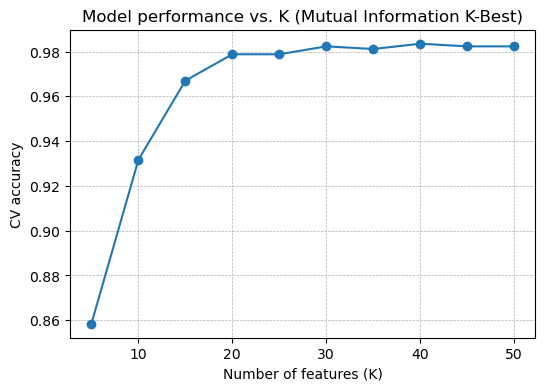

Saved MI K-curve to figures/mi_k_curve.png


In [136]:
# Keep only numeric features
X_num = X.select_dtypes(include=["number"])

# MI curve
ks, accs = accuracy_vs_k_MI(
    X_num, y,
    estimator=LogisticRegression(max_iter=2000, solver="lbfgs"),
    show=True, block=False, save_path="figures/mi_k_curve.png"
)
print("Saved MI K-curve to figures/mi_k_curve.png")


# Unsupervised Learning Methods

To handle unsupervised feature selection a wrapper is written which loops over candidate feature subsets, fits KMeans, gets cluster assignments, computes silhouette score and keeps the best subset

In [30]:
from preprocessing import unsup_wrapper_select
from sklearn.metrics import silhouette_score

X_km, selected_km, sil_km, hist_km = unsup_wrapper_select(X_train_fs,
                                                          KMeans,
                                                          {"n_clusters": 5, "n_init": 1},
                                                          n_features_to_select=15,
                                                          mode="fixed")

print("\nBest subset:", selected_km)
print("Best silhouette score:", sil_km)

# Plot
import matplotlib.pyplot as plt
steps, feats, scores = zip(*hist_km)   # <-- use hist_km, not hist
plt.plot(steps, scores, marker="o")
plt.xlabel("Number of Features")
plt.ylabel("Silhouette Score")
plt.title("Unsupervised Wrapper Feature Selection (KMeans)")
plt.show()


NameError: name 'X_train_fs' is not defined

In [ ]:
from fcmeans import FCM 

X_fcm, selected_fcm, sil_fcm, hist_fcm = unsup_wrapper_select(
    X_train_fs,
    FCM,
    {"n_clusters": 5},
    n_features_to_select=15,
    mode="fixed"
)

print("\nBest subset (FCM):", selected_fcm)
print("Best silhouette score (FCM):", sil_fcm)


ModuleNotFoundError: No module named 'skfuzzy'

c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Window

Step 1 | Added: grav_x_dom_freq | silhouette=0.988


c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Window

Step 2 | Added: gyro_z_dom_freq | silhouette=0.785


c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Window

...

Step 8 | Added: acc_x_iqr | silhouette=0.563


c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Window

Step 9 | Added: gyro_mag_spec_centroid | silhouette=0.552


c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Window

Step 10 | Added: grav_mag_max | silhouette=0.537
Selected features (GMM): ['grav_x_dom_freq']
Best silhouette score (GMM): 0.987639750554187


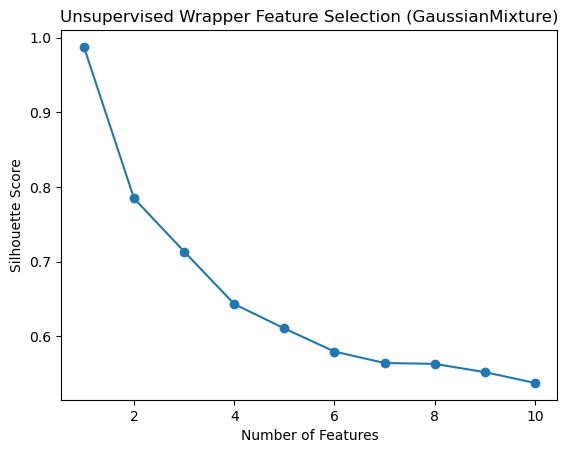

In [ ]:
# Run wrapper
X_gmm, selected_gmm, sil_gmm, hist_gmm = unsup_wrapper_select(
    #X_train_fs,
    pd.DataFrame(X_train_num, columns=feature_names)
    GaussianMixture,
    {"n_components": 5, "covariance_type": "full"},
    n_features_to_select=10,
    mode="fixed"
)

print("Selected features (GMM):", selected_gmm)
print("Best silhouette score (GMM):", sil_gmm)


if hist_gmm:  # make sure history is not empty
    steps, feats, scores = zip(*hist_gmm)
    plt.plot(steps, scores, marker="o")
    plt.xlabel("Number of Features")
    plt.ylabel("Silhouette Score")
    plt.title("Unsupervised Wrapper Feature Selection (GaussianMixture)")
    plt.show()
else:
    print("No valid clusters formed, nothing to plot.")


In [152]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

# Keep only numeric features for training
X_train_num = X_train.select_dtypes(include=["number"])
X_test_num  = X_test.select_dtypes(include=["number"])

# Train supervised model
clf = LogisticRegression(max_iter=5000, solver="lbfgs", random_state=42)
clf.fit(X_train_num, y_train)

# Predictions
y_pred_sup = clf.predict(X_test_num)

# Metrics
acc_sup = accuracy_score(y_test, y_pred_sup)
f1_sup  = f1_score(y_test, y_pred_sup, average="weighted")
kappa_sup = cohen_kappa_score(y_test, y_pred_sup)

print("Supervised Results:")
print("  Accuracy:", acc_sup)
print("  F1:", f1_sup)
print("  Kappa:", kappa_sup)


Supervised Results:
  Accuracy: 0.9704142011834319
  F1: 0.9725139018101374
  Kappa: 0.9490103789524499


c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

# Models you want to train
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, solver="lbfgs", random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

results = {}

# Keep only numeric features for training
X_train_num = X_train.select_dtypes(include=["number"])
X_test_num  = X_test.select_dtypes(include=["number"])

X_train_np = X_train_num.to_numpy()
X_test_np  = X_test_num.to_numpy()


for name, model in models.items():
    if name == "K-Nearest Neighbors":
        model.fit(X_train_np, y_train)
        y_pred = model.predict(X_test_np)
    else:
        model.fit(X_train_num, y_train)
        y_pred = model.predict(X_test_num)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="weighted")
    kappa = cohen_kappa_score(y_test, y_pred)

    results[name] = {"Accuracy": acc, "F1": f1, "Kappa": kappa}

# Print results
for model, metrics in results.items():
    print(f"\n{model} Results:")
    for m, val in metrics.items():
        print(f"  {m}: {val:.4f}")



Logistic Regression Results:
  Accuracy: 0.9704
  F1: 0.9725
  Kappa: 0.9490

Decision Tree Results:
  Accuracy: 0.9763
  F1: 0.9763
  Kappa: 0.9582

Naive Bayes Results:
  Accuracy: 0.9290
  F1: 0.9392
  Kappa: 0.8802

K-Nearest Neighbors Results:
  Accuracy: 0.9467
  F1: 0.9439
  Kappa: 0.9057


c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:

# Supervised & Unsupervised Training Script


import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from scipy.optimize import linear_sum_assignment
import skfuzzy as fuzz   


# Utility functions

def align_clusters(y_true, y_pred):
    """Align cluster labels to ground truth using Hungarian matching."""
    cm = confusion_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    return np.array([mapping[c] for c in y_pred])

def eval_model(name, y_true, y_pred):
    """Print Accuracy, F1, and Kappa for a model."""
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="weighted")
    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"\n{name} Results:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1:       {f1:.4f}")
    print(f"  Kappa:    {kappa:.4f}")


# Assume you already have:
# X_train, X_test, y_train, y_test


#  Keep only numeric columns
X_train_num = X_train.select_dtypes(include=["number"])
X_test_num  = X_test.select_dtypes(include=["number"])

#  Convert labels to numeric
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

#  Standard scaling (optional but helps LR/KNN/GMM)
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_num)
X_test_num  = scaler.transform(X_test_num)


# Supervised Models


supervised_models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, solver="lbfgs", random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

for name, model in supervised_models.items():
    model.fit(X_train_num, y_train_enc)
    y_pred = model.predict(X_test_num)
    eval_model(name, y_test_enc, y_pred)

# Unsupervised Models

# KMeans 
kmeans = KMeans(n_clusters=len(np.unique(y_train_enc)), n_init=10, random_state=42)
kmeans.fit(X_train_num)
y_pred_test = kmeans.predict(X_test_num)


y_aligned_kmeans = align_clusters(y_test_enc, y_pred_test)
eval_model("KMeans", y_test_enc, y_aligned_kmeans)

# Internal metric (on train set)
sil_kmeans = silhouette_score(X_train_num, kmeans.labels_)
print(f"KMeans Silhouette (train): {sil_kmeans:.3f}")

# Gaussian Mixture 
gmm = GaussianMixture(n_components=len(np.unique(y_train_enc)), random_state=42)
gmm.fit(X_train_num)
y_pred_gmm = gmm.predict(X_test_num)
y_aligned_gmm = align_clusters(y_test_enc, y_pred_gmm)
eval_model("Gaussian Mixture", y_test_enc, y_aligned_gmm)

# Fuzzy C-Means: INTERPRETER ERRORS
"""
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_test_num.T, 
    c=len(np.unique(y_train_enc)), 
    m=2.0, 
    error=0.005, 
    maxiter=1000, 
    init=None, 
    seed=42
)

y_pred_fcm = np.argmax(u, axis=0)
y_aligned_fcm = align_clusters(y_test_enc, y_pred_fcm)
eval_model("Fuzzy C-Means", y_test_enc, y_aligned_fcm)
"""



Logistic Regression Results:
  Accuracy: 0.9882
  F1:       0.9874
  Kappa:    0.9792

Decision Tree Results:
  Accuracy: 0.9882
  F1:       0.9887
  Kappa:    0.9792

Naive Bayes Results:
  Accuracy: 0.9231
  F1:       0.9335
  Kappa:    0.8702

K-Nearest Neighbors Results:
  Accuracy: 0.9763
  F1:       0.9758
  Kappa:    0.9581


c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(



KMeans Results:
  Accuracy: 0.7396
  F1:       0.7975
  Kappa:    0.6090
KMeans Silhouette (train): 0.309

Gaussian Mixture Results:
  Accuracy: 0.7633
  F1:       0.8165
  Kappa:    0.6305


c:\Users\ozdep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


'\ncntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(\n    X_test_num.T, \n    c=len(np.unique(y_train_enc)), \n    m=2.0, \n    error=0.005, \n    maxiter=1000, \n    init=None, \n    seed=42\n)\n\ny_pred_fcm = np.argmax(u, axis=0)\ny_aligned_fcm = align_clusters(y_test_enc, y_pred_fcm)\neval_model("Fuzzy C-Means", y_test_enc, y_aligned_fcm)\n'

In [ ]:
##############################################################################

Imports

In [9]:
# Imports:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
from models import *
import warnings
warnings.filterwarnings("ignore")


Re-load Dataset

In [10]:
# Load Dataset
DATASET_PATH = PROJECT_ROOT / "dataset.csv"
df = pd.read_csv(DATASET_PATH)

# X: all columns except first (Labels) and last (meta); y: first column
X = df.iloc[:, 1:-1].values
y_raw = df.iloc[:, 0].values


Standardize Features and Convert Class Labels to Integers

In [11]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Encode labels to integers for metrics
le = LabelEncoder()
y_true = le.fit_transform(y_raw)


### K-Means Clustering


Accuracies for k=1..5: {1: 0.5619158878504673, 2: 0.794392523364486, 3: 0.7558411214953271, 4: 0.7850467289719626, 5: 0.7336448598130841}

K-Means (k=5) Results:
  Accuracy: 0.7336
  F1:       0.5357
  Kappa:    0.6044


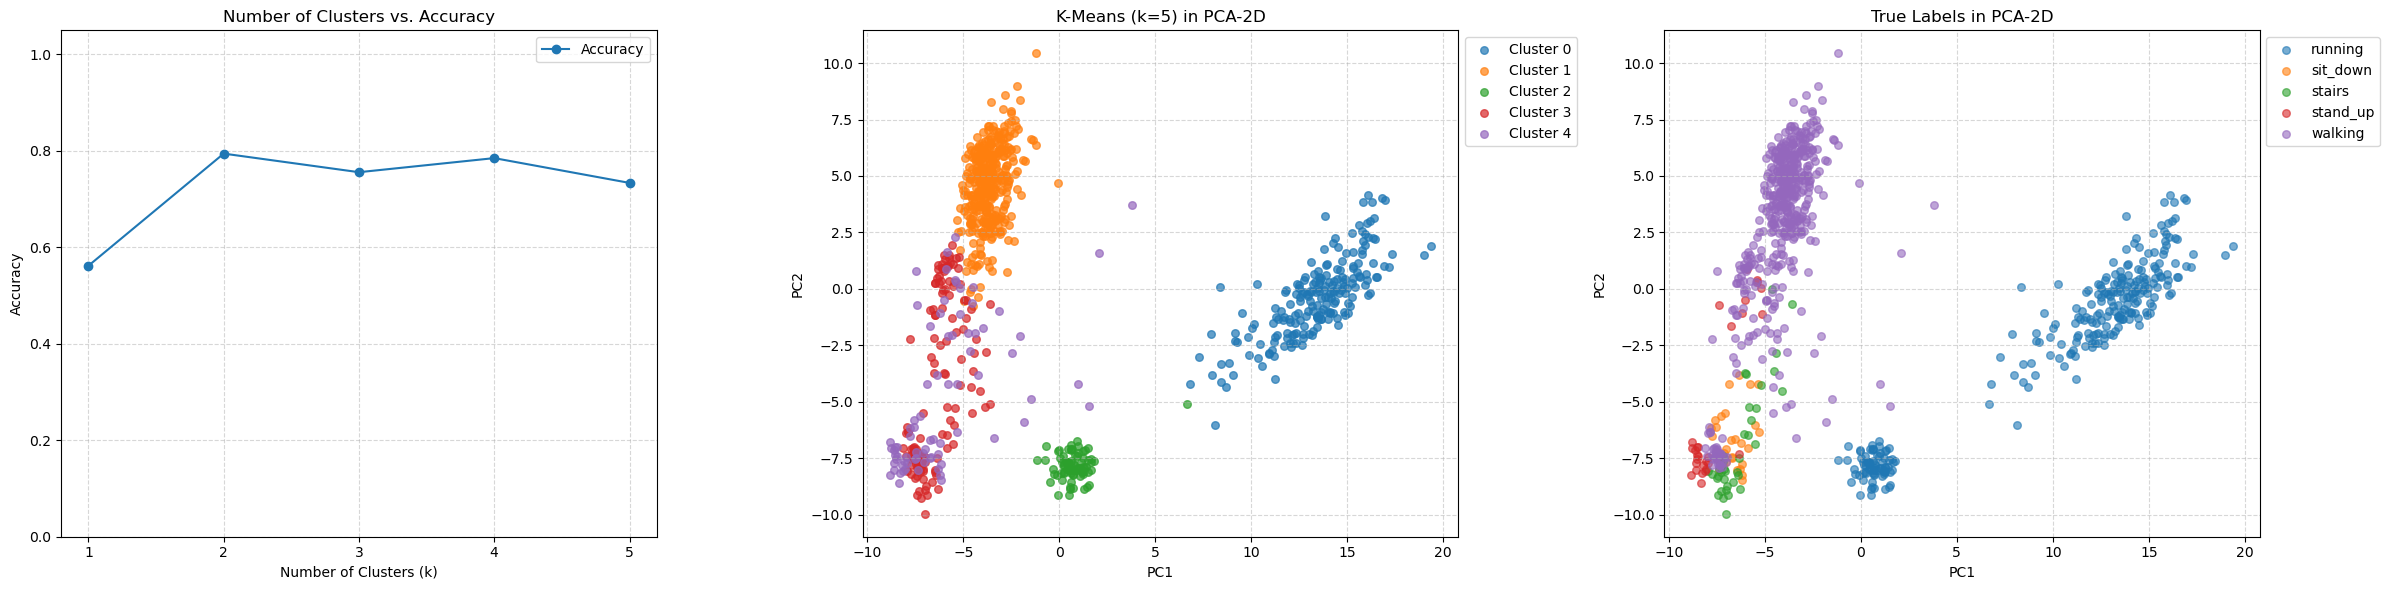

In [12]:
from sklearn.cluster import KMeans

# KMeans for k = 1..5
cluster_range = range(1, 6)
kmeans_results = []

for k in cluster_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = km.fit_predict(X_scaled)
    kmeans_results.append(clusters)

# Accuracy for each k (contingency max-per-cluster)
accuracies = []
for clusters in kmeans_results:
    y_k_aligned = align_clusters(y_true, clusters)
    accuracies.append(accuracy_score(y_true, y_k_aligned))
print("Accuracies for k=1..5:", dict(zip(cluster_range, accuracies)))

# Detailed metrics for k = 5
clusters_k5 = kmeans_results[-1]   # Last => k=5

# Optimal 1-1 cluster->label mapping
y_pred_aligned = align_clusters(y_true, clusters_k5)

# Compute Scores
acc5, f1_score5, kappa5 = eval_model("K-Means (k=5)", y_true, y_pred_aligned)

# Plot Results
plot_clustering_results("K-Means", X_scaled, y_true, le,
                        cluster_range, accuracies, clusters_k5)


### Fuzzy C-Means Clustering

Accuracies for k=1..5: {1: 0.5619158878504673, 2: 0.8212616822429907, 3: 0.7266355140186916, 4: 0.6658878504672897, 5: 0.6320093457943925}

K-Means (k=5) Results:
  Accuracy: 0.6320
  F1:       0.4118
  Kappa:    0.4825


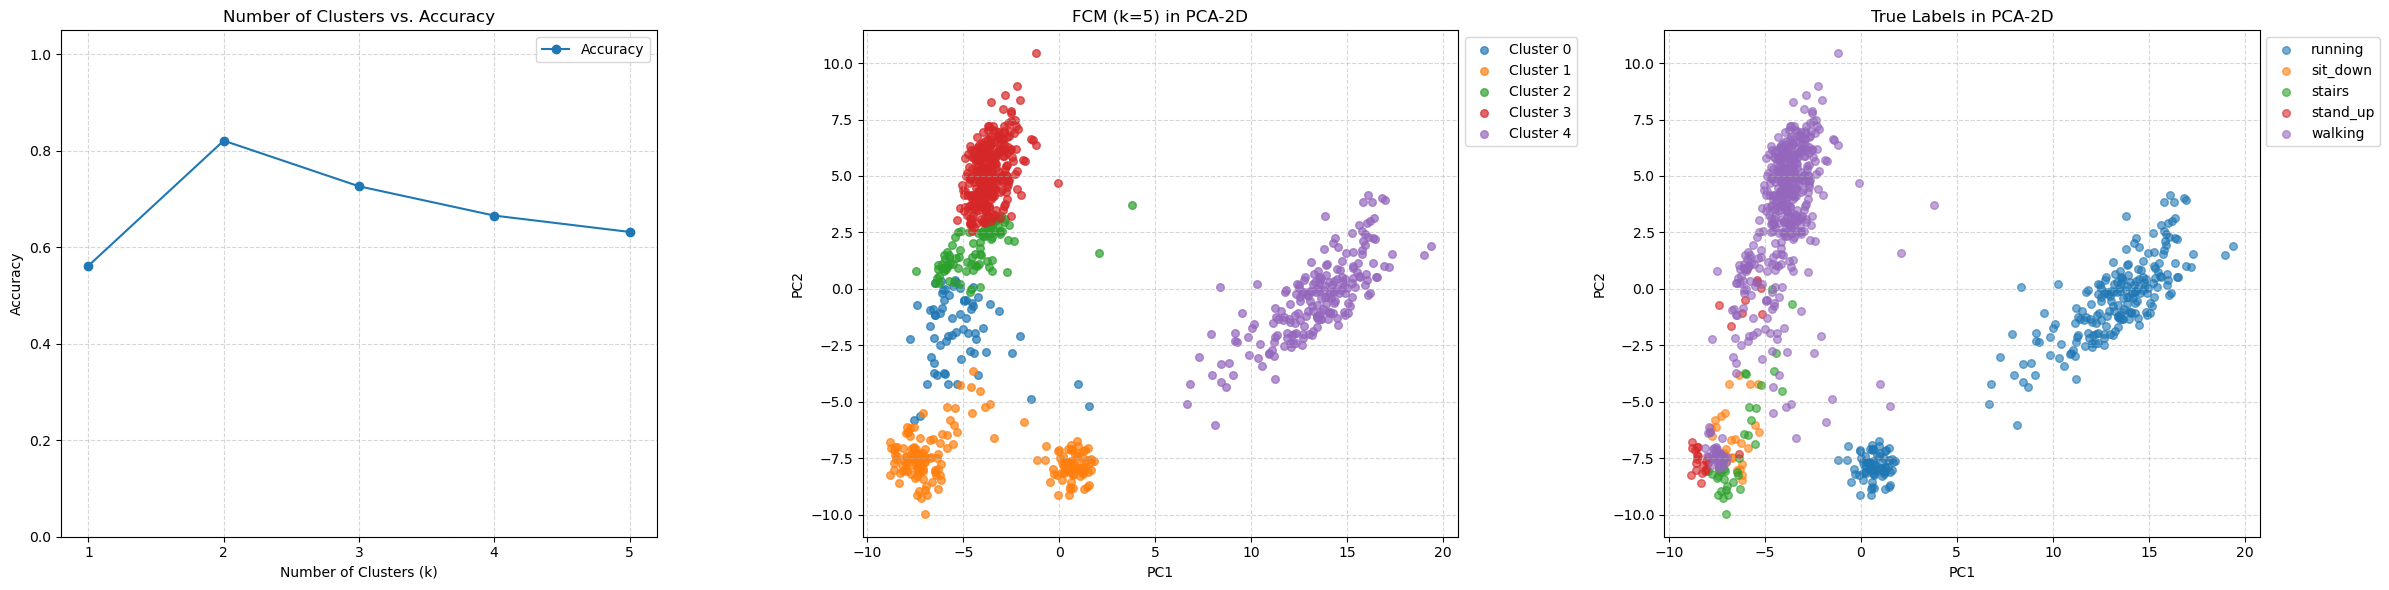

In [14]:
import skfuzzy as fuzz

# Fuzzy C-Means for k = 1..5
cluster_range = range(1, 6)
all_clusters = []

for k in cluster_range:
    # skfuzzy expects shape = (features, samples)
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(X_scaled.T, 
                                                    c=k, 
                                                    m=2.0, 
                                                    error=0.005, 
                                                    maxiter=1000, 
                                                    init=None)

    clusters = np.argmax(u, axis=0)     # hard labels from memberships
    all_clusters.append(clusters)

# Accuracy for each k (after optimal mapping)
accuracies = []
for clusters in all_clusters:
    y_pred_aligned = align_clusters(y_true, clusters)
    accuracies.append(accuracy_score(y_true, y_pred_aligned))
print("Accuracies for k=1..5:", dict(zip(cluster_range, accuracies)))

# Detailed metrics for k = 5
clusters_k5 = all_clusters[-1]
y_aligned_k5 = align_clusters(y_true, clusters_k5)

# Compute Scores
acc5, f1_score5, kappa5 = eval_model("K-Means (k=5)", y_true, y_aligned_k5)

# Plot Results
plot_clustering_results("FCM", X_scaled, y_true, le,
                        cluster_range, accuracies, clusters_k5)


In [172]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# Gaussian Mixture for k = 1..5
cluster_range = range(1, 6)
gmm_accuracies = []
gmm_silhouettes = []

for k in cluster_range:
    gmm = GaussianMixture(n_components=k, random_state=42, covariance_type="full")
    labels = gmm.fit_predict(X_scaled)

    # Align to ground truth for external metrics
    aligned = align_clusters(y_true, labels)
    gmm_accuracies.append(accuracy_score(y_true, aligned))

    # Silhouette for internal metric
    if k > 1:                                  # silhouette requires at least 2 clusters
        gmm_silhouettes.append(silhouette_score(X_scaled, labels))
    else:
        gmm_silhouettes.append(np.nan)

print("GMM Accuracies for k=1..5:", dict(zip(cluster_range, gmm_accuracies)))

# ---- Plot accuracy vs k ----
plt.figure(figsize=(6,4))
plt.plot(cluster_range, gmm_accuracies, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Accuracy (aligned)")
plt.title("GMM – Accuracy vs k")
plt.grid(True)
plt.show()

# ---- Plot silhouette vs k ----
plt.figure(figsize=(6,4))
plt.plot(cluster_range, gmm_silhouettes, marker='o', color='orange')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("GMM – Silhouette vs k")
plt.grid(True)
plt.show()


NameError: name 'X_scaled' is not defined